In [56]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier  ## pour le model de classification 
from sklearn.linear_model import LinearRegression #  Pour la regression lineairw
from sklearn.model_selection import train_test_split   # Pour la separation des donnnes du test et d'entrainment

In [57]:
##Classification est  un  model qui est utiliser pour entrainer des categories de donnes 

# 1-) Regression linaire

In [58]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [59]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


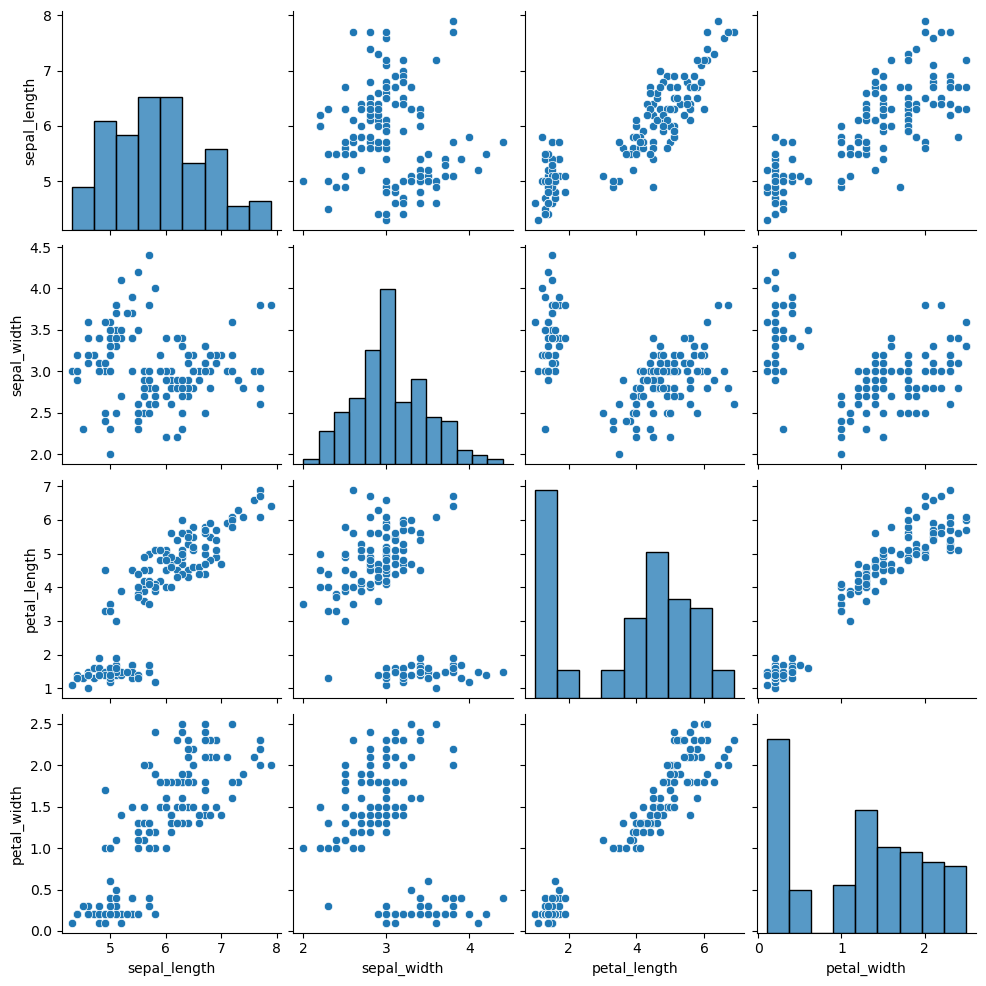

In [60]:
sns.pairplot(iris)

<Axes: xlabel='petal_length', ylabel='petal_width'>

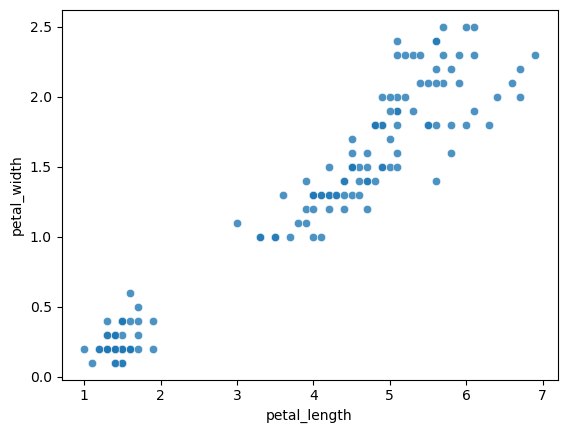

In [61]:
sns.scatterplot(data = iris , x = "petal_length", y = "petal_width", alpha = 0.8)

In [62]:
y= iris["petal_length"]
X = iris[["petal_width", "sepal_width", "sepal_length"]]

In [63]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [64]:
model = LinearRegression()
model.fit(X_train, y_train)  #Entrainement du model 
model.score(X_train, y_train)

0.9698225247940602

In [65]:
model.score(X_test, y_test)

0.9603293155857664

In [66]:
print(f"Entrainement : {model.score(X_train, y_train)}")
print(f"Evaluation   : {model.score(X_test, y_test)}")

Entrainement : 0.9698225247940602
Evaluation   : 0.9603293155857664


In [67]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv = 5)
print(f"Score moyen : {scores.mean()}")

Score moyen : 0.28469900184144536


## Classifiacation

In [87]:
titanic = sns.load_dataset("titanic")

In [88]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [89]:
titanic = titanic[["survived", "sex","pclass", "age"]]
titanic.head()

,survived,sex,pclass,age
0,0,male,3,22.0
1,1,female,1,38.0
2,1,female,3,26.0
3,1,female,1,35.0
4,0,male,3,35.0


In [91]:
titanic["sex"] = titanic["sex"].replace({
    "female" : 1,
    "male" : 0
})
titanic.dropna(axis = 0, inplace = True)

In [92]:
titanic.head()

,survived,sex,pclass,age
0,0,0,3,22.0
1,1,1,1,38.0
2,1,1,3,26.0
3,1,1,1,35.0
4,0,0,3,35.0


In [93]:
print(f"Nombre de lignes : {titanic.shape[0]}\n\n")
titanic.info()

Nombre de lignes : 714


<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   sex       714 non-null    int64  
 2   pclass    714 non-null    int64  
 3   age       714 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 27.9 KB


In [94]:
titanic.shape[0]

714

In [95]:
titanic["age"] = titanic["age"].astype(int)

In [96]:
titanic.head()

,survived,sex,pclass,age
0,0,0,3,22
1,1,1,1,38
2,1,1,3,26
3,1,1,1,35
4,0,0,3,35


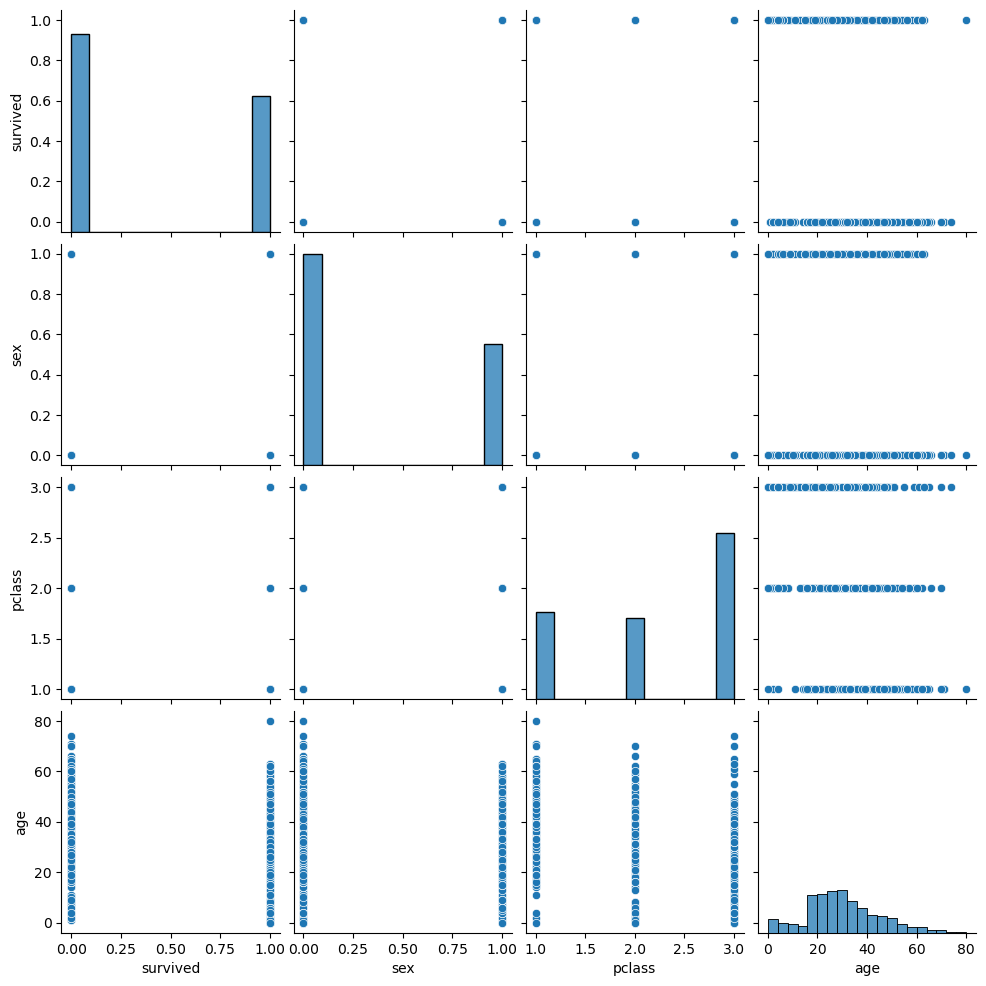

In [97]:
sns.pairplot(titanic)

<Axes: >

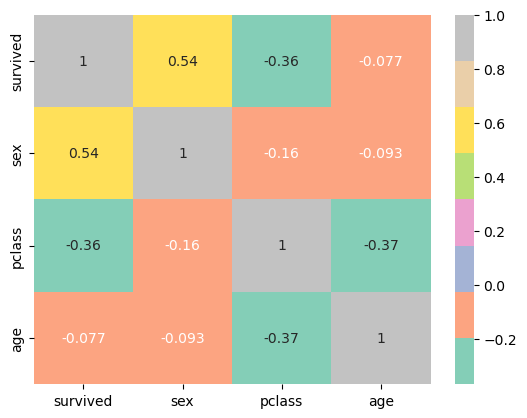

In [98]:
sns.heatmap(titanic.corr(numeric_only = True), alpha = 0.8, annot= True, cmap = "Set2")

In [99]:
X = titanic[["age", "sex", "pclass"]]   
y = titanic["survived"]              

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
model = KNeighborsClassifier(n_neighbors =1)
model.fit(X, y)
res = model.score(X_train, y_train)

In [101]:
print(f"Entrainement :{round(res, 2)*100 }%")

Entrainement :86.0%


In [102]:
score = cross_val_score(model, X, y, cv = 5)
score

array([0.72027972, 0.76223776, 0.78321678, 0.76923077, 0.73943662])

In [103]:
score_model = score.mean()
print(f"Test_val : {score_model.round(2)*100} %")

Test_val : 75.0 %


In [104]:
r = model.score(X_test, y_test)

In [105]:
print(f"Entrainement finale : {round(r, 2)*100}%")

Entrainement finale : 84.0%


## Les fleurs d'iris

In [106]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


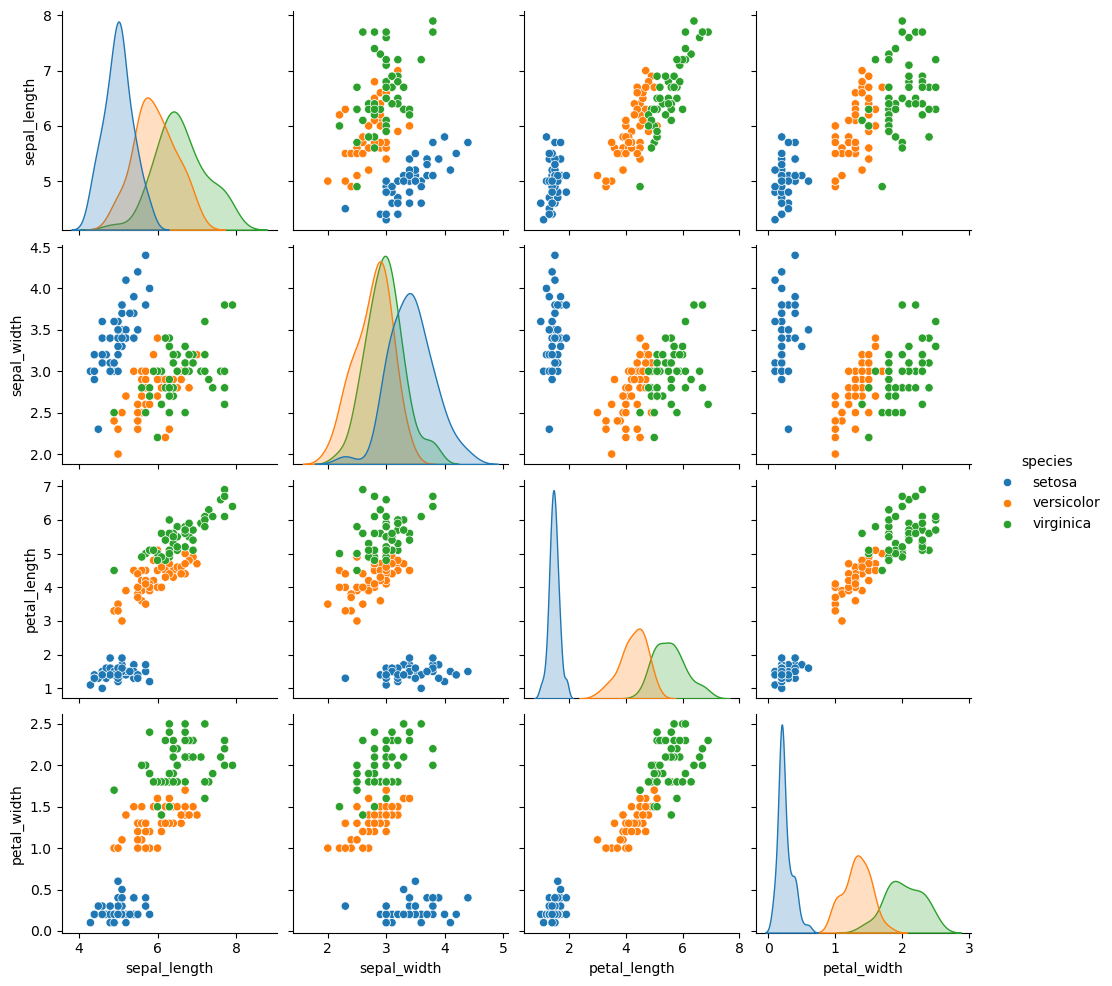

In [108]:
sns.pairplot(iris, hue = "species")

In [199]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [200]:
X =iris[["sepal_length", "sepal_width",	"petal_length",	"petal_width"]]
y = iris["species"]

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2, random_state  = 5)

In [202]:
print(f"Donnnes Entrainement : {X_train.shape}")
print(f"Donnees D'evaluation  : {X_test.shape}")

Donnnes Entrainement : (120, 4)
Donnees D'evaluation  : (30, 4)


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

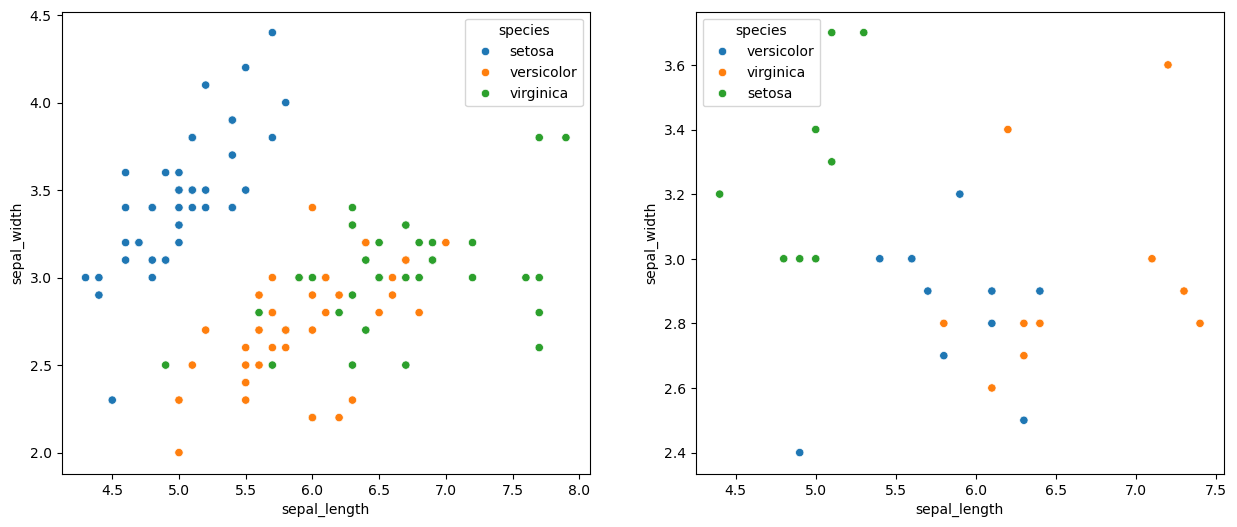

In [203]:
plt.figure(figsize = (15, 6))
plt.subplot(1,2,1)
sns.scatterplot(data = X_train,x ="sepal_length", y = "sepal_width", hue =y_train) 
plt.subplot(1,2,2)
sns.scatterplot(data = X_test,x ="sepal_length", y = "sepal_width", hue =y_test) 

In [207]:
model = KNeighborsClassifier (n_neighbors = 6) # Reglage et optimiation
model.fit(X_train, y_train)
resultat_score = model.score(X_train, y_train) 

print(f"\nScore a l'entrainement du model :{round(resultat_score*100, 2)}%\n")


Score a l'entrainement du model :98.33%



<h4 style="color : blue">Validation set</h3>

- On utilise un validation set pour vérifier si le modèle fonctionne bien sur des données qu’il n’a pas vues pendant son entraînement, et surtout pour choisir les meilleurs paramètres du modèle avant l’évaluation finale.

<h3 style = "color : blue">Cross validation</h3>


- La cross-validation est utilisée pour évaluer un modèle de manière plus fiable. Au lieu de séparer les données une seule fois en entraînement et        test, on les divise en plusieurs parties et on entraîne le modèle plusieurs fois. À chaque fois, une partie différente sert à la validation. Ensuite,   on calcule la moyenne des résultats.

     En gros, elle permet de vérifier que les performances du modèle ne dépendent pas simplement d’un seul découpage des données.

In [208]:
from sklearn.model_selection import cross_val_score # importation du module 

In [245]:
data_valide = cross_val_score(KNeighborsClassifier(), X_train, y_train, cv = 5, scoring = "accuracy")

In [246]:
print(f"Score de validation : {round(data_valide.mean(), 2)}")

Score de validation : 0.98


Text(0, 0.5, 'Score')

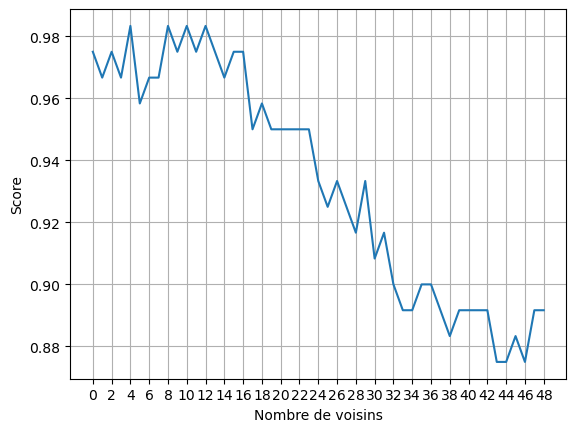

In [309]:
val_score = []
for i in range(1, 50):
    resultat  = cross_val_score(KNeighborsClassifier(n_neighbors = i), X_train, y_train, cv = 5).mean()
    val_score.append(resultat)

plt.plot(val_score)
plt.grid()
plt.xticks(ticks = np.arange(0, 50, 2))
plt.xlabel("Nombre de voisins")
plt.ylabel("Score")

<h3 style = "color : blue">Validation Curve</h3>

La Validation Curve sert à voir comment les performances d’un modèle évoluent lorsque l’on change un paramètre.

Par exemple, avec KNN, on peut tester plusieurs valeurs de n_neighbors : 1, 3, 5, 7, 10…

On observe ensuite les scores d’entraînement et de validation.

Elle permet donc de trouver une bonne valeur du paramètre et de détecter si le modèle fait du sous-apprentissage ou du surapprentissage.

In [267]:
from sklearn.model_selection import validation_curve

model = KNeighborsClassifier()
k = np.arange(1, 50) # l'iterateur
train_score, val_score = validation_curve(model, X_train, y_train,
                                          param_name = "n_neighbors", param_range = k, cv = 5)
#Chaque ligne  de val_score contient les 5 score de valiation 
moyenne_score_val  = val_score.mean(axis = 1)
moyenne_score_train = train_score.mean(axis = 1)
moyenne_score

print(f"Donnees de l'entrainment :\n{moyenne_score_train}\n\nDonnees de validadtion :\n {moyenne_score_val}\n")

Donnees de l'entrainment :
[1.         0.98333333 0.97916667 0.97708333 0.98125    0.975
 0.97708333 0.97291667 0.97708333 0.975      0.97708333 0.97291667
 0.97708333 0.97291667 0.975      0.96666667 0.96666667 0.9625
 0.96041667 0.95625    0.95833333 0.95833333 0.96041667 0.95625
 0.95833333 0.95208333 0.95       0.93541667 0.93958333 0.93541667
 0.93958333 0.93125    0.92291667 0.91666667 0.925      0.91666667
 0.9125     0.91458333 0.91666667 0.91458333 0.91041667 0.91041667
 0.90625    0.89583333 0.90208333 0.90208333 0.90416667 0.89791667
 0.89791667]

Donnees de validadtion :
 [0.975      0.96666667 0.975      0.96666667 0.98333333 0.95833333
 0.96666667 0.96666667 0.98333333 0.975      0.98333333 0.975
 0.98333333 0.975      0.96666667 0.975      0.975      0.95
 0.95833333 0.95       0.95       0.95       0.95       0.95
 0.93333333 0.925      0.93333333 0.925      0.91666667 0.93333333
 0.90833333 0.91666667 0.9        0.89166667 0.89166667 0.9
 0.9        0.89166667 0.883333

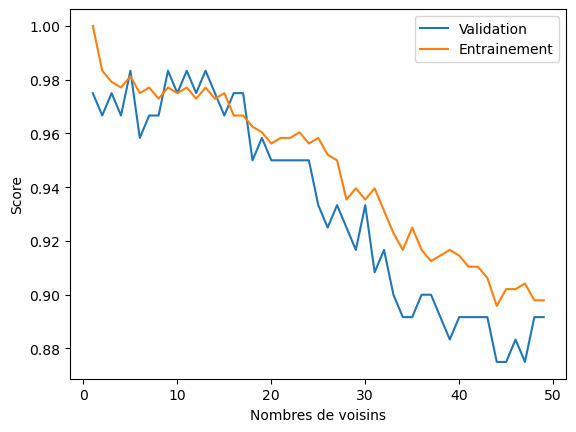

In [269]:
plt.plot(k, moyenne_score_val, label = "Validation") # On retrouve le meme avec celui avec range
plt.plot(k, moyenne_score_train, label = "Entrainement")
plt.ylabel("Score")
plt.xlabel("Nombres de voisins")
plt.legend()

Avec ce grapiphique on sait desormains qu'on peut atteindre 98% de performance en choisissant la bonne valeur pour l'hyper_parametre ***n_neighbors*** 

<h3 style = "color : blue">Overfeting</h3>

Dans le cas du surapprentissage (overfitting), le modèle apprend trop bien les données d’entraînement, jusqu’à mémoriser leurs particularités et leurs erreurs.

Par exemple, si le score d’entraînement est 98 % mais que le score de validation est seulement 65 %, cela signifie que le modèle fonctionne très bien sur les données qu’il connaît, mais mal sur de nouvelles données.

La Validation Curve permet justement de repérer ce problème en comparant le score d’entraînement et le score de validation

<h3 style = "color : blue">GridSearchCV</h3>

***GridSearchCV*** est utilisé pour trouver automatiquement les meilleurs paramètres d’un modèle.

Par exemple, avec KNN, tu peux tester plusieurs valeurs de n_neighbors comme 3, 5, 7, 9. GridSearchCV teste différentes combinaisons de paramètres avec la validation croisée, puis sélectionne celle qui donne le meilleur score.

En gros : GridSearchCV = tester plusieurs réglages + validation croisée + choisir le meilleur réglage.

In [271]:
from sklearn.model_selection import GridSearchCV

In [272]:
param_grid = {"n_neighbors":np.arange(1,20),
    "metric" : ["euclidean", "manhattan"]
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv = 5)
grid

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])})

In [273]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])})

In [310]:
print(f"Le meilleur Score : {round(grid.best_score_, 2)*100}%")

Le meilleur Score : 98.0%


In [315]:
grid.best_params_  # ,meilleur parametre

{'metric': 'euclidean', 'n_neighbors': np.int64(5)}

In [317]:
model_Grid_Search = grid.best_estimator_ # Recuperation du meilleur modele 

In [313]:
model_Grid_Search.score(X_test,y_test) #Test et analyse du score sur les dconnes reserve pour l'evaluation du module

0.9333333333333333

**CONFUSION MATRIX**

- Outils de mesure de tres utile pour evaluer la qualite d'une modele de classification 
- Montre les erreurs de classement

La matrice de confusion (Confusion Matrix) sert à voir où un modèle de classification se trompe.

Elle compare les vraies classes avec les classes prédites par le modèle. Cela permet de voir, par exemple, combien de fleurs Iris ont été correctement classées et combien ont été confondues avec une autre espèce.

En gros : la matrice de confusion permet de comprendre les erreurs et les bonnes prédictions du modèle, classe par classe.

In [288]:
from sklearn.metrics import confusion_matrix  #cette fonction vient du module metrics

In [294]:
confusion_matrix(y_test, model_Grid_Search.predict(X_test))

array([[ 8,  0,  0],
       [ 0,  9,  2],
       [ 0,  0, 11]])

On suppose que les lignes = vraies classes et les colonnes = classes prédites.

- Classe 0 : 8 correctement prédites, aucune erreur.
- Classe 1 : 9 correctement prédites, mais 2 ont été prédites comme classe 2.
- Classe 2 : 11 correctement prédites, aucune erreur.

Donc mon modèle a fait 28 bonnes prédictions sur 30.

Son taux de réussite est donc :

28 / 30 ≈ 93,3 %

 Le seul problème du modèle est qu'il confond parfois la classe 1 avec la classe 2.

<h3 style = "color : blue">Learning_curve (Courbe d'apprentissage)</h3>

La Learning Curve permet de voir comment les performances du modèle évoluent lorsqu’on augmente la quantité de données d’entraînement.

- Elle compare généralement le score d’entraînement et le score de validation.
- Elle permet surtout de savoir si le modèle a besoin de plus de données et de détecter un éventuel surapprentissage (overfitting) ou sous-apprentissage (underfitting).

In [295]:
from sklearn.model_selection import learning_curve

train_sizes: Contrôle les proportions (ou nombres absolus) de l'ensemble de données de formation utilisé pour générer la courbe d'apprentissage.

Retours:

    - N: Le nombre réel d'échantillons de formation utilisés à chaque fraction.

    - train_score: Tableau de scores d'entraînement avec forme (len(train_sizes), cv).

    - val_score: Tableau de scores de validation avec forme (len(train_sizes), cv).

In [298]:
N, train_score, val_score = learning_curve(model_Grid_Search, X_train,  y_train,
                                           train_sizes = np.linspace(0.1, 1.0, 10), 
                                           cv= 5
)

In [299]:
N

array([ 9, 19, 28, 38, 48, 57, 67, 76, 86, 96])

In [300]:
train_score

array([[1.        , 0.88888889, 0.88888889, 0.88888889, 0.88888889],
       [0.94736842, 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 0.97916667, 1.        , 1.        , 1.        ],
       [1.        , 0.98245614, 1.        , 1.        , 1.        ],
       [0.97014925, 0.97014925, 0.98507463, 1.        , 1.        ],
       [0.97368421, 0.97368421, 0.98684211, 1.        , 1.        ],
       [0.96511628, 0.96511628, 0.97674419, 0.98837209, 0.98837209],
       [0.97916667, 0.96875   , 0.97916667, 0.98958333, 0.98958333]])

In [301]:
val_score

array([[0.875     , 0.58333333, 0.625     , 0.66666667, 0.66666667],
       [1.        , 0.91666667, 0.95833333, 0.95833333, 0.95833333],
       [1.        , 1.        , 1.        , 0.95833333, 0.95833333],
       [1.        , 1.        , 1.        , 0.95833333, 0.95833333],
       [1.        , 0.95833333, 1.        , 0.95833333, 0.95833333],
       [1.        , 1.        , 1.        , 0.95833333, 0.95833333],
       [1.        , 1.        , 1.        , 0.95833333, 0.91666667],
       [1.        , 0.95833333, 1.        , 0.95833333, 0.95833333],
       [1.        , 1.        , 1.        , 0.95833333, 0.95833333],
       [1.        , 1.        , 1.        , 0.95833333, 0.95833333]])

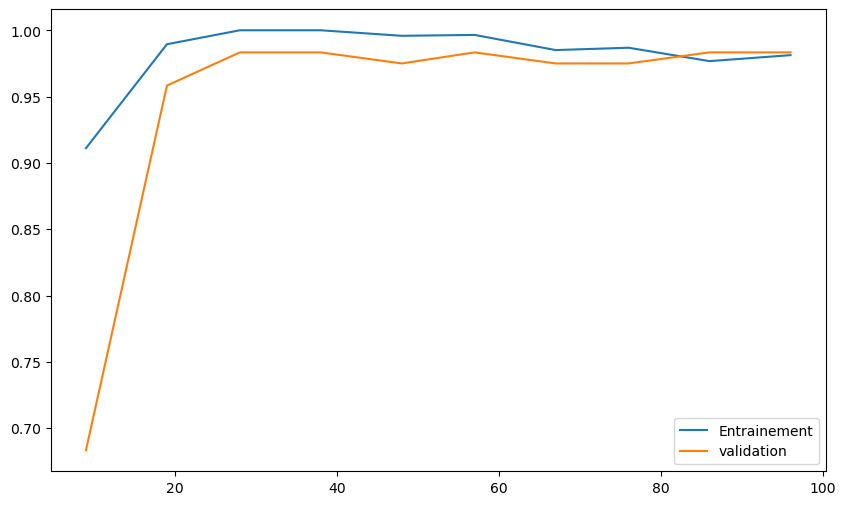

In [306]:
plt.figure (figsize = (10, 6))
plt.plot(N, train_score.mean(axis = 1), label = "Entrainement")
plt.plot(N, val_score.mean(axis = 1), label = "validation")
plt.legend()

# Conclusion : Workflow d'apprentissage en Machine Learning (KNN)

### 1) Créer un Train set et un Test set, puis entraîner et évaluer
* **Séparation :** Diviser les données avec `train_test_split` pour conserver un ensemble de test indépendant.
* **Entraînement initial :** Ajuster le modèle KNN de base sur `X_train` et mesurer sa performance initiale.

### 2) Optimiser avec `GridSearchCV`
* **Recherche d'hyperparamètres :** Trouver la combinaison optimale des paramètres :
  * `n_neighbors` (nombre de voisins)
  * `weights` (`'uniform'` ou `'distance'`)
  * `metric` (`'euclidean'`, `'manhattan'`, etc.)

### 3) Est-ce que collecter plus de données serait utile ? (`learning_curve`)
* **Analyse de la courbe d'apprentissage :**
  * **Si les 2 courbes (train et validation) convergent vers un plateau :** Inutile de collecter plus de données, le modèle a atteint sa capacité maximale.
  * **S'il reste un grand écart entre la courbe train et validation :** Ajouter des données permettra d'améliorer la généralisation (réduire l'overfitting).

### 4) Évaluation finale et partage
* Valider la performance globale du modèle optimisé sur le **Test set** et partager les résultats !

In [320]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [372]:
df.dropna(inplace = True)
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

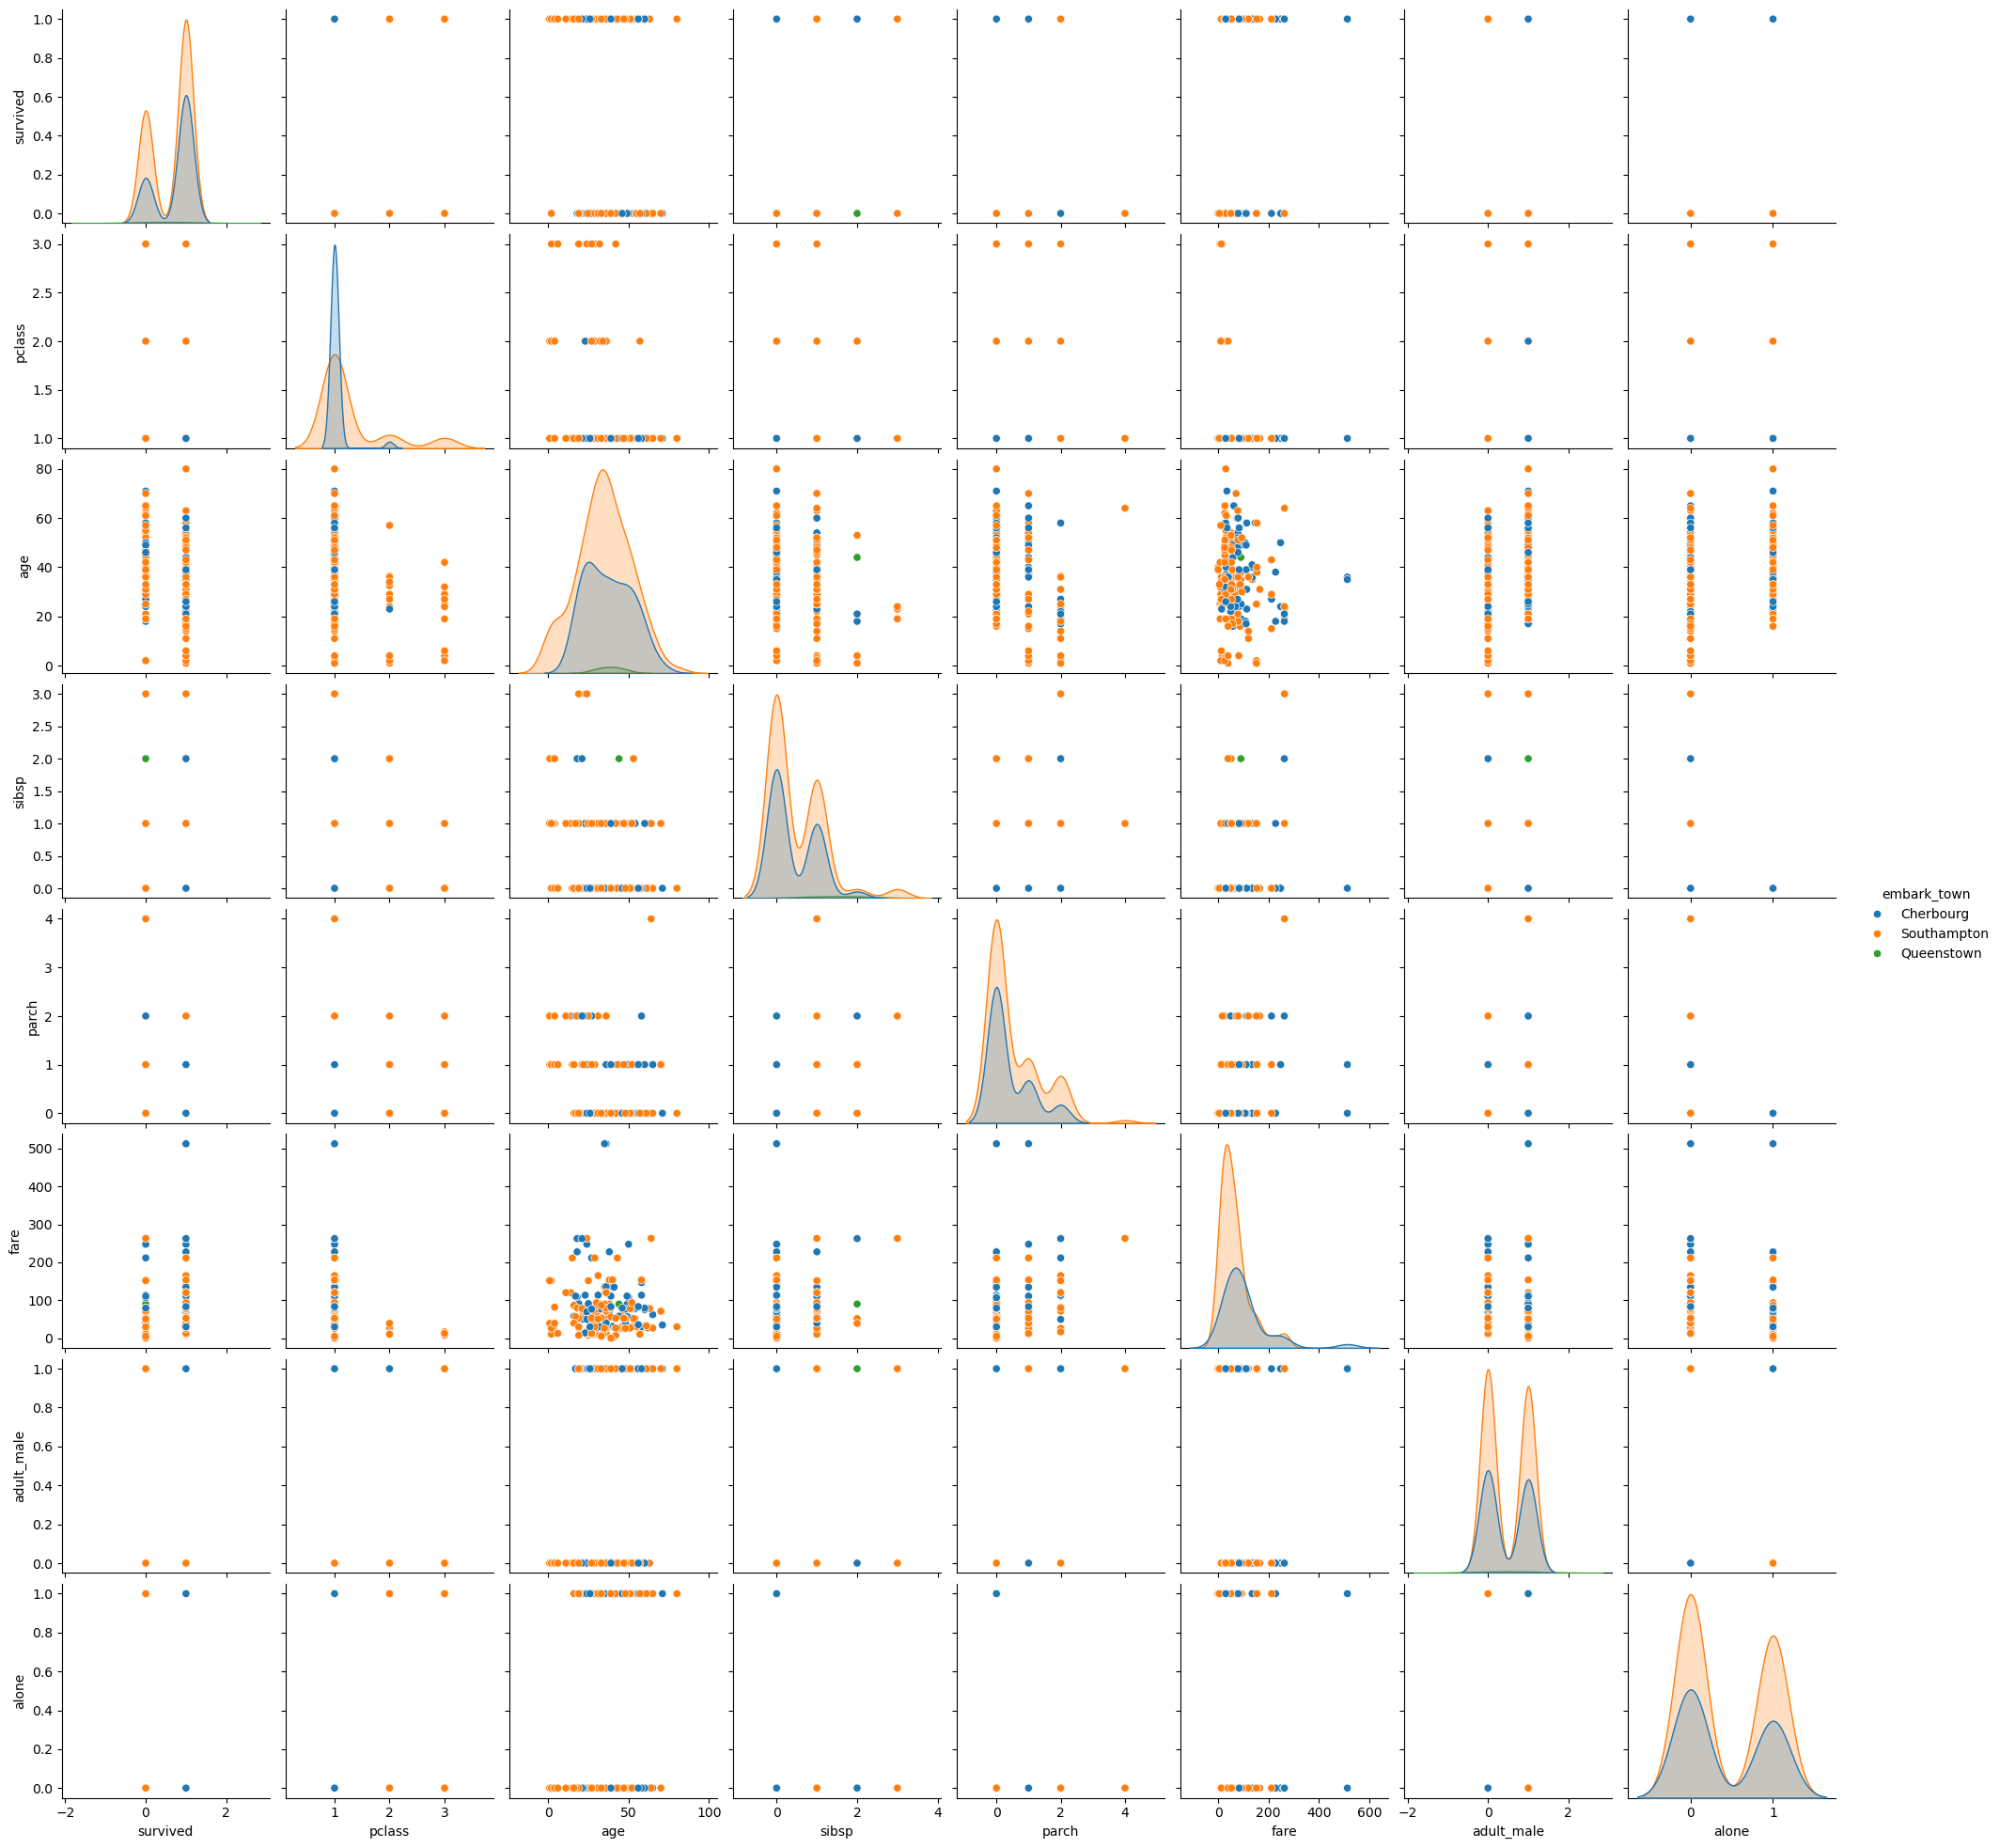

In [373]:
sns.pairplot(df, hue  = "embark_town")

In [374]:
X = df[["age","pclass"]]
y = df["embark_town"]

<Axes: xlabel='age', ylabel='pclass'>

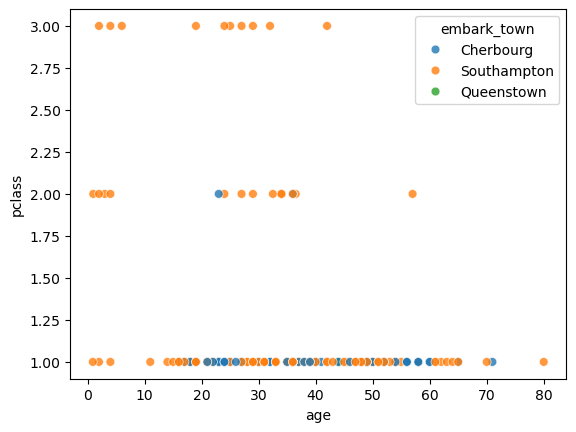

In [375]:
sns.scatterplot(data = X,  x = "age", y = "pclass", hue = y, s = 40, alpha = 0.8)

In [376]:
# Separation des donnes (Train set et test set)
# from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5)

print(f"- Train set  : {X_train.shape}\n- test set : {X_test.shape}")

- Train set  : (145, 2)
- test set : (37, 2)


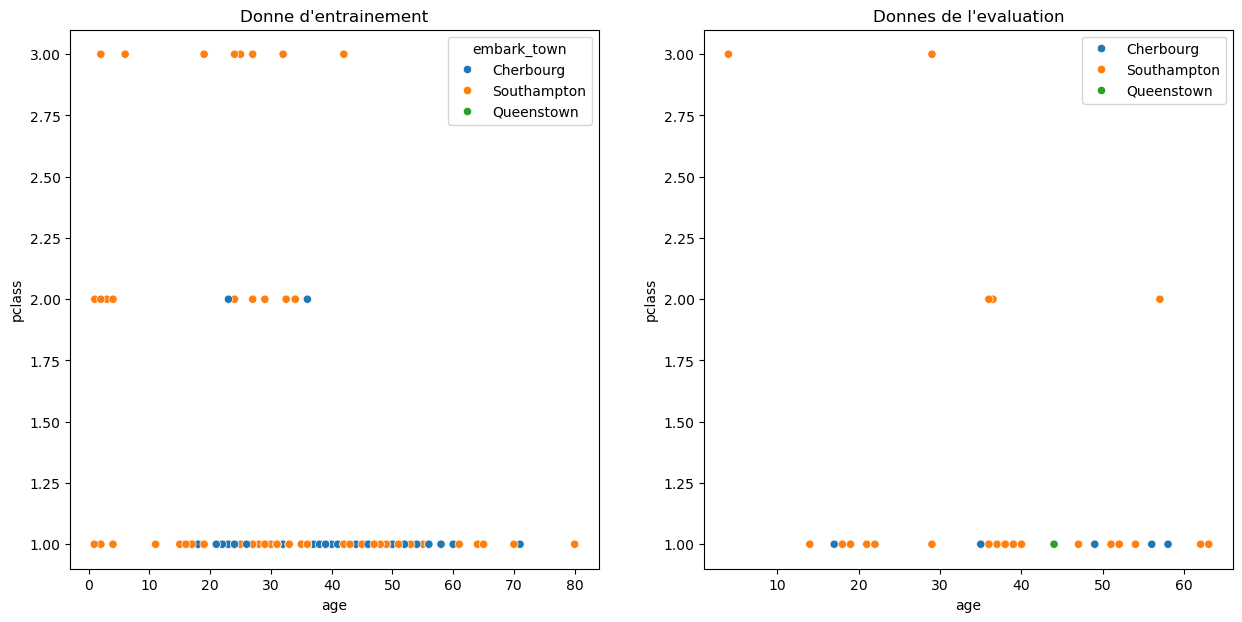

In [377]:
plt.figure(figsize = (15, 7))
plt.subplot(1,2,1)
plt.title("Donne d'entrainement")
sns.scatterplot(data = X_train, x = "age", y = "pclass", hue = y)
plt.subplot(1,2,2)
plt.title("Donnes de l'evaluation")
sns.scatterplot(data = X_test, x = "age", y = "pclass", hue = y)
plt.legend()

In [378]:
# from sklearn.neighbors import KNeighborsClassifier()

In [380]:
modele = KNeighborsClassifier()
modele.fit(X_train , y_train)
modele.score(X_train, y_train) # Score obtenu a l'entraine=ment

0.7310344827586207

-  ***Amedilorons le modele avec les reglages de parametres***

In [382]:
# from sklearn.model_selection import cross_val_score

In [397]:
score_val = cross_val_score(KNeighborsClassifier(), X_train, y_train, cv = 5)
score_val = score_val.mean()
print(f" Score a l'evaluation du model avec cross_val :  {round(score_val, 1)*100}%" )  # Par defaut 

 Score a l'evaluation du model avec cross_val :  60.0%


C:\Users\dc\anacondau\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


C:\Users\dc\anacondau\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dc\anacondau\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dc\anacondau\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dc\anacondau\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dc\anacondau\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dc\anacondau\Lib\site-packages\sklea

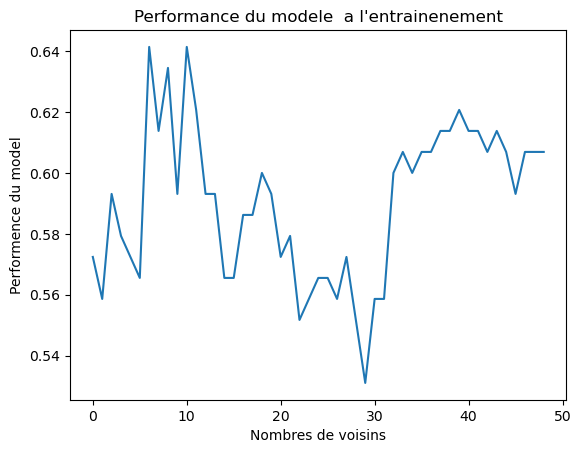

In [411]:
score  = []
for i in range(1, 50):
    result = cross_val_score(KNeighborsClassifier(n_neighbors= i), X_train, y_train, cv =5).mean()
    score.append(result)

plt.title("Performance du modele  a l'entrainenement")
plt.plot(score)
plt.xlabel("Nombres de voisins")
plt.ylabel("Performence du model")

plt.show()

 - Utilisons ***validation curve*** pour tracer l'evoliuton de la performance de notre model 

In [ ]:
sklearn.model_selection import validation_curve

In [414]:
train_score, val_score = validation_curve(KNeighborsClassifier(), X_train , y_train,
                                          param_name = "n_neighbors", param_range = np.arange(1,50, 5), cv =5)

train_score # #Les scores de a l'entrainment avec modification du parametteew n_neighbors

C:\Users\dc\anacondau\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


array([[0.75      , 0.79310345, 0.77586207, 0.81034483, 0.74137931],
       [0.63793103, 0.70689655, 0.69827586, 0.63793103, 0.74137931],
       [0.68965517, 0.68103448, 0.73275862, 0.62931034, 0.68965517],
       [0.6637931 , 0.63793103, 0.67241379, 0.62068966, 0.65517241],
       [0.62068966, 0.64655172, 0.62931034, 0.62931034, 0.6637931 ],
       [0.57758621, 0.62931034, 0.61206897, 0.55172414, 0.60344828],
       [0.5862069 , 0.60344828, 0.59482759, 0.61206897, 0.62068966],
       [0.60344828, 0.60344828, 0.62068966, 0.61206897, 0.5862069 ],
       [0.60344828, 0.60344828, 0.61206897, 0.61206897, 0.61206897],
       [0.60344828, 0.60344828, 0.61206897, 0.61206897, 0.61206897]])

In [415]:
val_score ## lES RRESULTAT DE VALIDATION 

array([[0.62068966, 0.55172414, 0.48275862, 0.44827586, 0.75862069],
       [0.62068966, 0.48275862, 0.51724138, 0.68965517, 0.51724138],
       [0.72413793, 0.5862069 , 0.48275862, 0.82758621, 0.5862069 ],
       [0.68965517, 0.48275862, 0.51724138, 0.62068966, 0.51724138],
       [0.62068966, 0.48275862, 0.55172414, 0.65517241, 0.55172414],
       [0.5862069 , 0.48275862, 0.5862069 , 0.62068966, 0.55172414],
       [0.55172414, 0.51724138, 0.62068966, 0.5862069 , 0.51724138],
       [0.62068966, 0.62068966, 0.65517241, 0.5862069 , 0.55172414],
       [0.62068966, 0.62068966, 0.65517241, 0.5862069 , 0.5862069 ],
       [0.62068966, 0.62068966, 0.55172414, 0.5862069 , 0.5862069 ]])

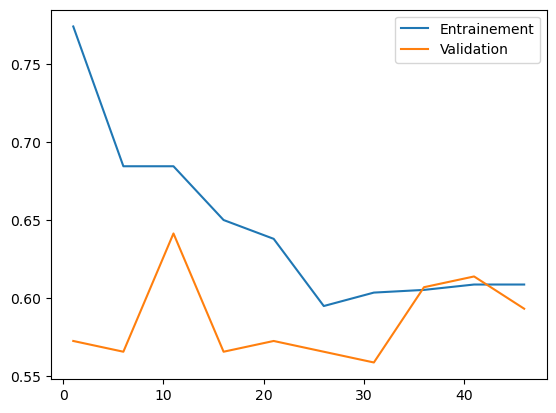

In [424]:
plt.plot(np.arange(1, 50,5), train_score.mean(axis =1), label = "Entrainement")
plt.plot(np.arange(1, 50,5), val_score.mean(axis =1), label = "Validation")
plt.legend()

In [425]:
#d'APRES LE GRAPHE NOTRE =MODELE PEUT ATTEINDRE UN PERFORAMCE ENVIRON 80%

In [ ]:
# DETERMINONS LES PARAMETRE DU MODELE LE PLUS MEILLEUR  POUR CELA ON VA UTILISER LA FONCTION GridSearchCV

In [428]:
# from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
                    
             param_grid={'metric': ['euclidean', 'manhattan'],
                         "n_neighbors":np.arange(1,20,1)
                        }
)

In [431]:
grid  # Le model qui va nous permettre de trouver le meilleur reglage

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])})

In [435]:
grid.fit(X_train, y_train)
print(f"Le meilleur score : {round(grid.best_score_, 2)*100} %")

C:\Users\dc\anacondau\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Le meilleur score : 64.0 %


In [448]:
grid.best_params_

{'metric': 'euclidean', 'n_neighbors': np.int64(7)}

In [449]:
mon_modele = grid.best_estimator_# Sauvegarde du nouveau model

In [450]:
print(f"Le Score sur les donne de l'evaluation : {round(mon_modele.score(X_test, y_test), 2)*100} %")

Le Score sur les donne de l'evaluation : 68.0 %


- ***Recherche de la matrice de confusion***

In [458]:
#from sklearn.metrics import confusion_matrix   # Pour comparer les valeur predites et les donnes reels

In [460]:
confusion_matrix(y_test, mon_modele.predict(X_test))

array([[ 5,  0,  4],
       [ 0,  0,  1],
       [ 7,  0, 20]])

# Interprétation de la Matrice de Confusion

### 1. Le résultat global
* **Échantillon total :** Sur **37 personnes**, le modèle a deviné juste pour **25 personnes**.
* **Précision globale (Accuracy) :** **67.6%** ($25 / 37$).

---

### 2. Analyse ligne par ligne (Ce qui s'est réellement passé)

* **Pour les 9 passagers de Cherbourg (C0) :**
  * Il en a trouvé **5** correctement.
  * Il s'est trompé pour **4** d'entre eux en prédisant qu'ils venaient de Southampton (C2).

* **Pour le seul passager de Queenstown (C1) :**
  * Il s'est trompé à **100%** : il l'a classé par erreur à Southampton (C2).
  * **Problème majeur :** Le modèle n'a **jamais** deviné Queenstown pour qui que ce soit.

* **Pour les 27 passagers de Southampton (C2) :**
  * Il en a trouvé **20** correctement.
  * Il s'est trompé pour **7** d'entre eux en prédisant qu'ils venaient de Cherbourg (C0).

---

### 3. Pourquoi le modèle fait-il ça ?

1. **Déséquilibre des classes (Class Imbalance) :**
   * Il y a trop de passagers de Southampton (27) et presque aucun de Queenstown (1). 
   * Le modèle KNN choisit la facilité : comme Southampton est ultra-majoritaire, il vote pour cette ville dès qu'il a un doute.

2. **Absence de mise à l'échelle (`StandardScaler`) :**
   * Pour un algorithme basé sur les distances comme le KNN, si l'âge varie de 0 à 80 ans et la classe de 1 à 3, la variable "âge" écrase complètement la variable "classe" dans les calculs de distance.